In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin-1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [4]:
df.drop([
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Product Image',
'Product Description'
], axis=1, inplace=True)

In [5]:
df.drop(['Order Zipcode'], axis=1, inplace=True)

In [6]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Id                      0
Customer Segment                 0
Customer State                   0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrders)          0
Order Id                         0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id       

In [7]:
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(df['Customer Zipcode'].median())

In [8]:
df.drop(['Delivery Status'], axis=1, inplace=True)

In [9]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [10]:
df['order_day'] = df['order date (DateOrders)'].dt.day
df['order_month'] = df['order date (DateOrders)'].dt.month

In [11]:
df.drop(['order date (DateOrders)', 'shipping date (DateOrders)'], axis=1, inplace=True)

In [12]:
df.drop([
'Customer City','Customer Country','Customer State',
'Order City','Order Country','Order State',
'Product Name','Category Name','Department Name'
], axis=1, inplace=True)

In [13]:
df.drop([
'Customer Id','Order Customer Id','Order Id',
'Order Item Id','Product Card Id','Order Item Cardprod Id'
], axis=1, inplace=True)

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 65 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Days for shipping (real)       180519 non-null  int64  
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Benefit per order              180519 non-null  float64
 3   Sales per customer             180519 non-null  float64
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Id                    180519 non-null  int64  
 6   Customer Zipcode               180519 non-null  float64
 7   Department Id                  180519 non-null  int64  
 8   Latitude                       180519 non-null  float64
 9   Longitude                      180519 non-null  float64
 10  Order Item Discount            180519 non-null  float64
 11  Order Item Discount Rate       180519 non-null  float64
 12  Order Item Product Price      

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [50]:
df.to_csv("digitivity/Data/supply_chain_cleaned.csv", index=False)

In [17]:
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred_rf = rf_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [23]:
df.drop([
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
], axis=1, inplace=True)

In [24]:
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.745956126744959


In [28]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 5.8 MB/s eta 0:00:18
   - -------------------------------------- 3.1/101.7 MB 6.5 MB/s eta 0:00:16
   - -------------------------------------- 5.0/101.7 MB 7.1 MB/s eta 0:00:14
   -- ------------------------------------- 6.6/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 7.9/101.7 MB 7.2 MB/s eta 0:00:13
   --- ------------------------------------ 8.9/101.7 MB 6.9 MB/s eta 0:00:14
   --- ------------------------------------ 9.4/101.7 MB 6.5 MB/s eta 0:00:15
   --- ------------------------------------ 9.7/101.7 MB 5.9 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/101.7 MB 5.4 MB/s eta 0:00:17
   ---- ----------------------------------- 10.5/101.7 MB 4.8 MB/s eta 0:00:20
   ---- ----------------------------------- 10.7/101.7 MB 4.6 MB/s eta 0:00:

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
y_pred_xgb = xgb_model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7324396188787946


In [34]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

print(comparison)

           Model  Accuracy
0  Random Forest  0.745956
1        XGBoost  0.732440


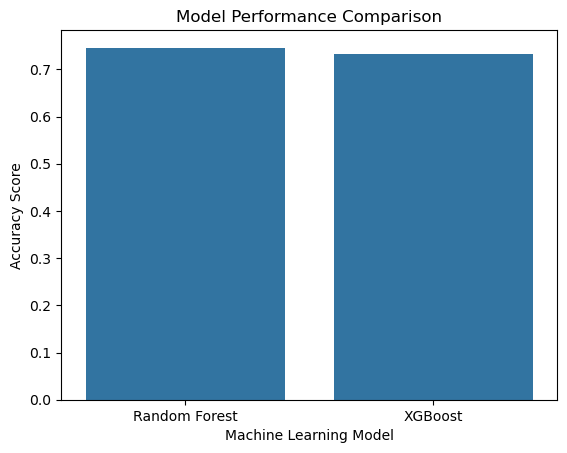

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="Accuracy", data=comparison)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy Score")
plt.xlabel("Machine Learning Model")
plt.savefig("digitivity/outputs/Model Performance Comparison.png")
plt.show()

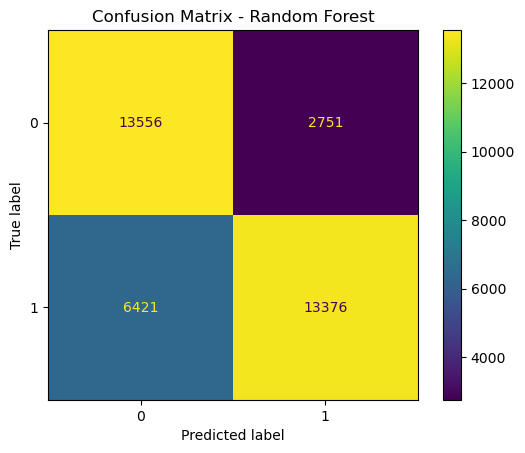

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.savefig("digitivity/outputs/Confusion Matrix - Random Forest.png")
plt.show()

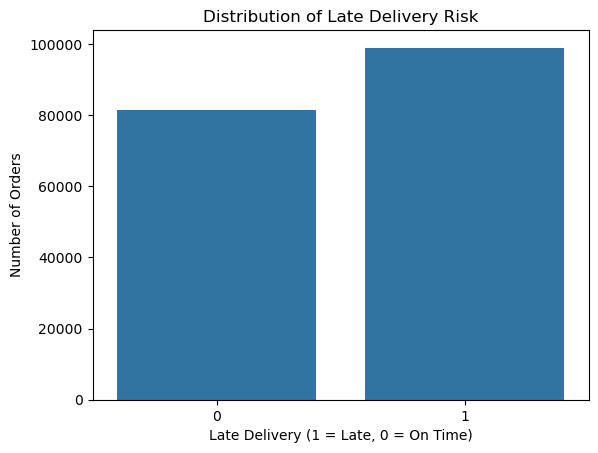

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Late_delivery_risk", data=df)

plt.title("Distribution of Late Delivery Risk")
plt.xlabel("Late Delivery (1 = Late, 0 = On Time)")
plt.ylabel("Number of Orders")
plt.savefig("digitivity/outputs/Distribution of Late Delivery Risk.png")
plt.show()

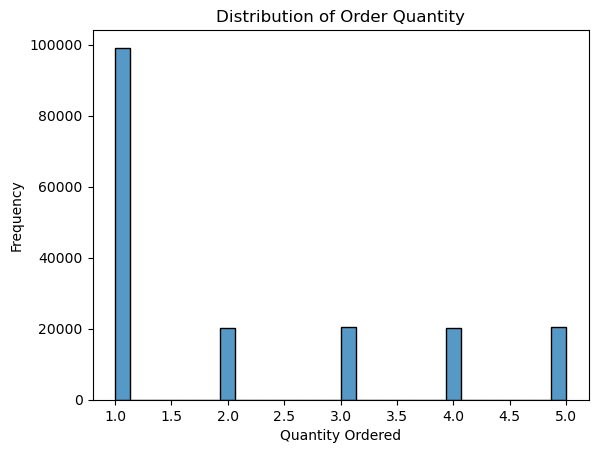

In [47]:
sns.histplot(df["Order Item Quantity"], bins=30)

plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")
plt.savefig("digitivity/outputs/Distribution of Order Quantity.png")
plt.show()

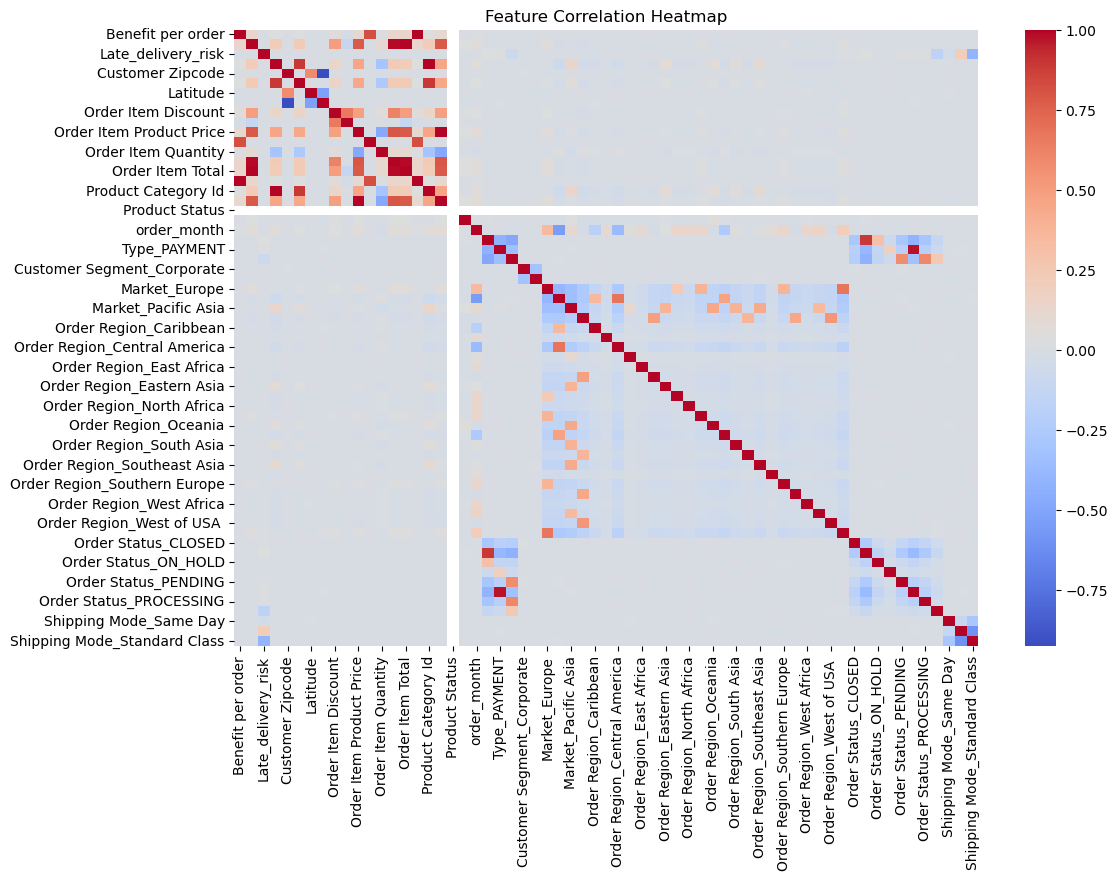

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.savefig("digitivity/outputs/Feature Correlation Heatmap.png")
plt.show()

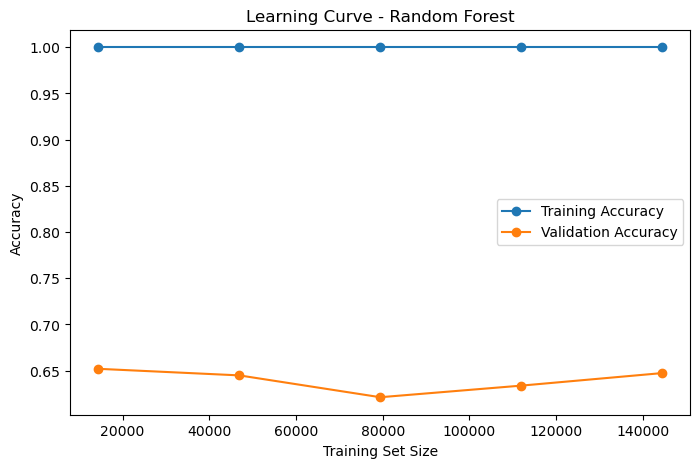

In [51]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Accuracy")

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("digitivity/outputs/model_learning_curve.png")
plt.show()